<a href="https://colab.research.google.com/github/bindal-tanmay/AI-Powered-Real-Time-Arrhythmia-Detection-Alert-System/blob/main/overall_ecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install pyserial tensorflow scikit-learn pandas numpy matplotlib seaborn -q
print('✅ All dependencies installed')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import (confusion_matrix, classification_report,
                                     r2_score, roc_curve, auc)
from sklearn.utils           import class_weight

import tensorflow as tf
from tensorflow.keras.models    import Sequential, load_model
from tensorflow.keras.layers    import (Conv1D, MaxPooling1D, LSTM, Dense,
                                         Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
from tensorflow.keras.utils     import to_categorical

# ── Config ──────────────────────────────────────────────────
SEED        = 42
DATA_DIR    = "/content"          # folder where CSVs are uploaded in Colab
MODEL_PATH  = "ecg_lstm_best.h5"
FS          = 360
N_CLASSES   = 5
BATCH_SIZE  = 64
EPOCHS      = 50

CLASS_NAMES = ['N — Normal', 'S — Supraventricular', 'V — Ventricular',
               'F — Fusion', 'Q — Unknown/Paced']
CLASS_SHORT = ['N', 'S', 'V', 'F', 'Q']
COLORS      = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports done')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

# List the contents of the downloaded dataset directory
print("\nContents of the dataset directory:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat

Contents of the dataset directory:
/kaggle/input/heartbeat/ptbdb_abnormal.csv
/kaggle/input/heartbeat/ptbdb_normal.csv
/kaggle/input/heartbeat/mitbih_test.csv
/kaggle/input/heartbeat/mitbih_train.csv


In [5]:
def load_mitbih_csv(data_dir):
    train_path = os.path.join(data_dir, "mitbih_train.csv")
    test_path  = os.path.join(data_dir, "mitbih_test.csv")
    print("📂 Loading MIT-BIH CSV files...")
    train_df = pd.read_csv(train_path, header=None)
    test_df  = pd.read_csv(test_path,  header=None)
    X_train = train_df.iloc[:, :-1].values.astype(np.float32)
    y_train = train_df.iloc[:,  -1].values.astype(int)
    X_test  = test_df.iloc[:,  :-1].values.astype(np.float32)
    y_test  = test_df.iloc[:,   -1].values.astype(int)
    print(f'   Train shape : {X_train.shape}')
    print(f'   Test shape  : {X_test.shape}')
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_mitbih_csv(path)
print('✅ Dataset loaded successfully')

📂 Loading MIT-BIH CSV files...
   Train shape : (87554, 187)
   Test shape  : (21892, 187)
✅ Dataset loaded successfully


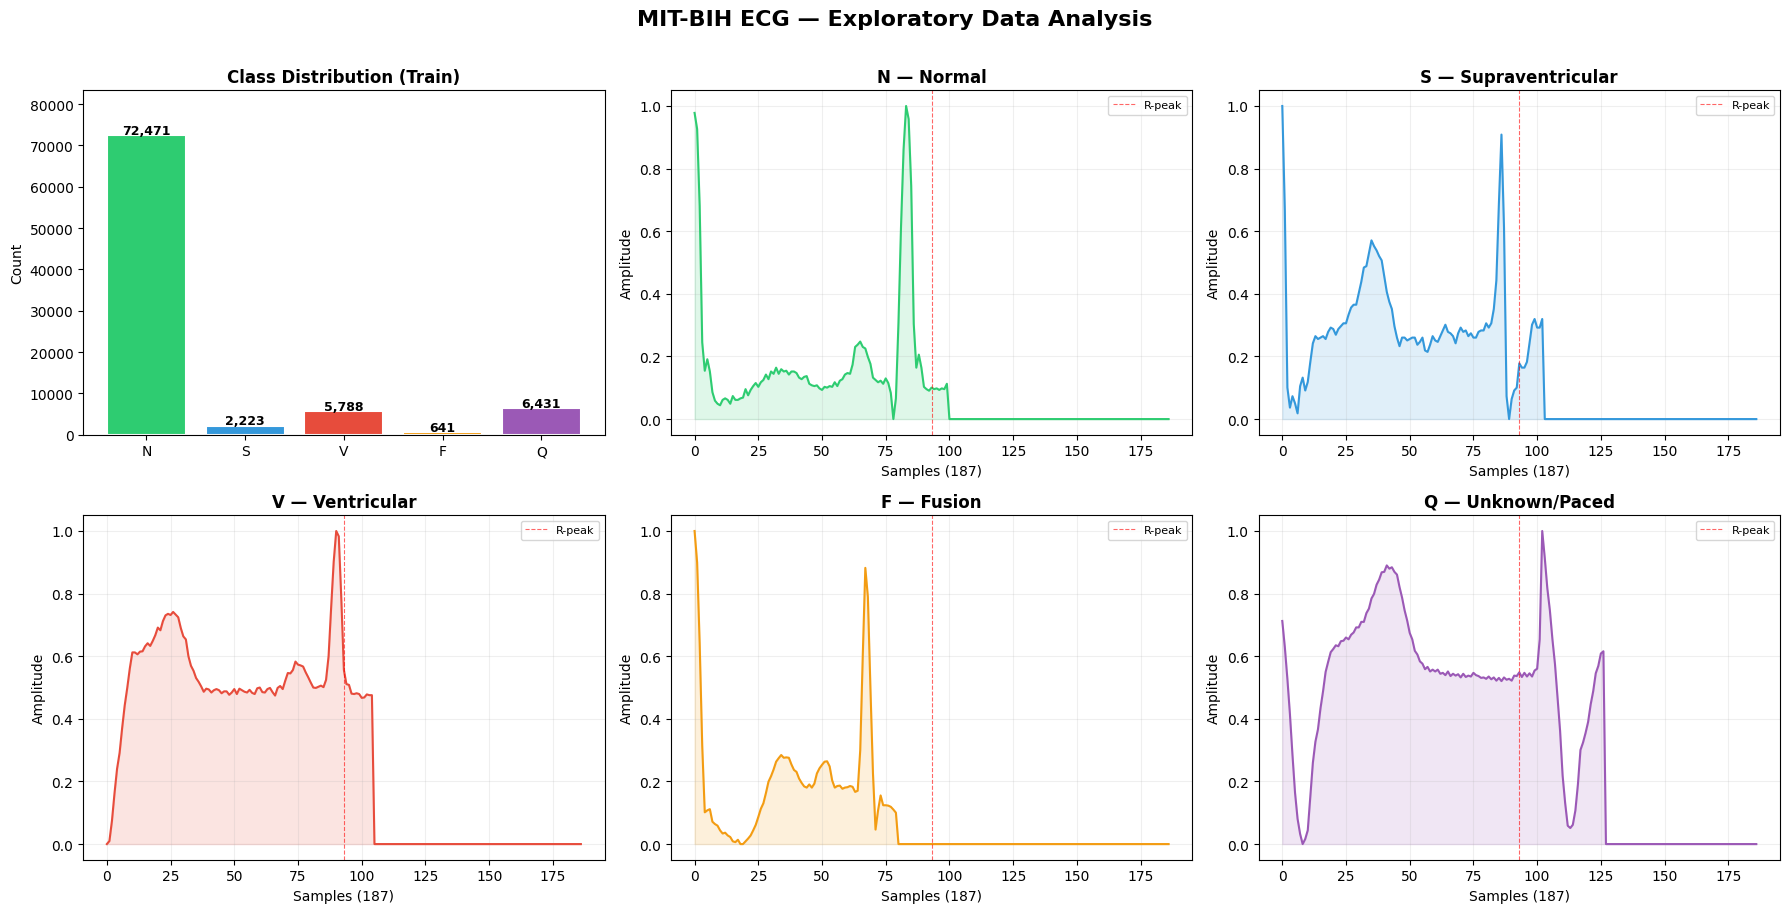

✅ EDA complete — eda_plot.png saved

📊 Class Distribution:
   N — Normal                     : 72,471 beats (82.8%)
   S — Supraventricular           :  2,223 beats (2.5%)
   V — Ventricular                :  5,788 beats (6.6%)
   F — Fusion                     :    641 beats (0.7%)
   Q — Unknown/Paced              :  6,431 beats (7.3%)


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('MIT-BIH ECG — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# Class distribution
ax = axes[0, 0]
counts = pd.Series(y_train).value_counts().sort_index()
bars = ax.bar(CLASS_SHORT, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax.set_title('Class Distribution (Train)', fontweight='bold')
ax.set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 300, f'{v:,}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.15)

# Sample beats per class
for cls_idx in range(5):
    r, c = divmod(cls_idx + 1, 3)
    ax = axes[r, c]
    sample = X_train[y_train == cls_idx][0]
    ax.plot(sample, linewidth=1.5, color=COLORS[cls_idx])
    ax.fill_between(range(len(sample)), sample, alpha=0.15, color=COLORS[cls_idx])
    ax.set_title(f'{CLASS_NAMES[cls_idx]}', fontweight='bold')
    ax.set_xlabel('Samples (187)')
    ax.set_ylabel('Amplitude')
    ax.axvline(x=93, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='R-peak')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete — eda_plot.png saved')
print(f'\n📊 Class Distribution:')
for i, (cls, cnt) in enumerate(zip(CLASS_NAMES, counts.values)):
    print(f'   {cls:<30} : {cnt:>6,} beats ({cnt/len(y_train)*100:.1f}%)')

In [7]:
def preprocess(X_train, y_train, X_test, y_test):
    print('⚙️  Preprocessing...')

    def normalize(X):
        mean = X.mean(axis=1, keepdims=True)
        std  = X.std(axis=1,  keepdims=True) + 1e-8
        return (X - mean) / std

    X_train_n = normalize(X_train)
    X_test_n  = normalize(X_test)

    # Reshape for LSTM: (samples, timesteps, features)
    X_train_n = X_train_n[..., np.newaxis]
    X_test_n  = X_test_n[..., np.newaxis]

    # One-hot encode
    y_train_cat = to_categorical(y_train, N_CLASSES)
    y_test_cat  = to_categorical(y_test,  N_CLASSES)

    # Class weights
    weights = class_weight.compute_class_weight(
        class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(weights))

    # Train / validation split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_n, y_train_cat, test_size=0.15,
        random_state=SEED, stratify=y_train)

    print(f'   Train   : {X_tr.shape}')
    print(f'   Val     : {X_val.shape}')
    print(f'   Test    : {X_test_n.shape}')
    print(f'   Class weights: { {CLASS_SHORT[k]: round(v,2) for k,v in class_weights.items()} }')
    return X_tr, X_val, X_test_n, y_tr, y_val, y_test_cat, class_weights

X_tr, X_val, X_te, y_tr, y_val, y_te_cat, class_weights = \
    preprocess(X_train, y_train, X_test, y_test)

# Keep raw test labels for evaluation
y_te_raw = y_test
print('✅ Preprocessing complete')

⚙️  Preprocessing...
   Train   : (74420, 187, 1)
   Val     : (13134, 187, 1)
   Test    : (21892, 187, 1)
   Class weights: {'N': np.float64(0.24), 'S': np.float64(7.88), 'V': np.float64(3.03), 'F': np.float64(27.32), 'Q': np.float64(2.72)}
✅ Preprocessing complete


In [8]:
def build_model(input_shape):
    model = Sequential([
        # CNN frontend
        Conv1D(32,  kernel_size=5, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(64,  kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        # LSTM
        LSTM(128, return_sequences=True,  dropout=0.2, recurrent_dropout=0.1),
        LSTM(64,  return_sequences=False, dropout=0.2, recurrent_dropout=0.1),
        # Classifier
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    model.summary()
    return model

model = build_model(input_shape=(X_tr.shape[1], 1))
print('✅ Model built')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 93, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 46, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,829 (866.52 KB)

 Trainable params: 221,253 (864.27 KB)

 Non-trainable params: 576 (2.25 KB)

✅ Model built


In [ ]:
# callbacks = [
#     EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max', verbose=1),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
#     ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True, mode='max', verbose=1)
# ]

# history = model.fit(
#     X_tr, y_tr,
#     validation_data=(X_val, y_val),
#     epochs=5,
#     batch_size=BATCH_SIZE,
#     class_weight=class_weights,
#     callbacks=callbacks,
#     verbose=1
# )
# print('✅ Training complete — best model saved to', MODEL_PATH)

from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,ModelCheckpoint)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,              # stop after 5 epochs of no improvement
        restore_best_weights=True,
        mode='max',
        verbose=1,
        min_delta=0.001          # ← ADD THIS: only counts as improvement
    ),                           #   if val_auc improves by at least 0.001
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,              # reduce LR faster too
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,              # ← set high, let EarlyStopping decide when to stop
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
print('✅ Training complete — best model saved to', MODEL_PATH)

Epoch 1/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3200 - auc: 0.6559 - loss: 1.3978
Epoch 1: val_auc improved from None to 0.87423, saving model to ecg_lstm_best.h5



Epoch 1: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 238s 197ms/step - accuracy: 0.4455 - auc: 0.7629 - loss: 1.1145 - val_accuracy: 0.5808 - val_auc: 0.8742 - val_loss: 1.0112 - learning_rate: 0.0010
Epoch 2/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6376 - auc: 0.8749 - loss: 0.7664
Epoch 2: val_auc improved from 0.87423 to 0.93126, saving model to ecg_lstm_best.h5



Epoch 2: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 260s 196ms/step - accuracy: 0.6857 - auc: 0.8993 - loss: 0.6912 - val_accuracy: 0.7313 - val_auc: 0.9313 - val_loss: 0.7169 - learning_rate: 0.0010
Epoch 3/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7384 - auc: 0.9221 - loss: 0.5724
Epoch 3: val_auc improved from 0.93126 to 0.95071, saving model to ecg_lstm_best.h5



Epoch 3: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 225s 194ms/step - accuracy: 0.7535 - auc: 0.9287 - loss: 0.5579 - val_accuracy: 0.8118 - val_auc: 0.9507 - val_loss: 0.5998 - learning_rate: 0.0010
Epoch 4/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7923 - auc: 0.9426 - loss: 0.4791
Epoch 4: val_auc did not improve from 0.95071
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 261s 193ms/step - accuracy: 0.8009 - auc: 0.9459 - loss: 0.4781 - val_accuracy: 0.8100 - val_auc: 0.9361 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 5/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8121 - auc: 0.9508 - loss: 0.4169
Epoch 5: val_auc improved from 0.95071 to 0.95171, saving model to ecg_lstm_best.h5



Epoch 5: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 230s 198ms/step - accuracy: 0.8275 - auc: 0.9562 - loss: 0.4132 - val_accuracy: 0.8306 - val_auc: 0.9517 - val_loss: 0.5896 - learning_rate: 0.0010
Epoch 6/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8394 - auc: 0.9621 - loss: 0.3653
Epoch 6: val_auc improved from 0.95171 to 0.95930, saving model to ecg_lstm_best.h5


...


Epoch 13: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 226s 195ms/step - accuracy: 0.8715 - auc: 0.9794 - loss: 0.2706 - val_accuracy: 0.8453 - val_auc: 0.9785 - val_loss: 0.3940 - learning_rate: 0.0010
Epoch 14/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8738 - auc: 0.9801 - loss: 0.2499
Epoch 14: val_auc did not improve from 0.97849
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 263s 195ms/step - accuracy: 0.8788 - auc: 0.9806 - loss: 0.2574 - val_accuracy: 0.8442 - val_auc: 0.9718 - val_loss: 0.4519 - learning_rate: 0.0010
Epoch 15/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8734 - auc: 0.9797 - loss: 0.2445
Epoch 15: val_auc did not improve from 0.97849
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 271s 203ms/step - accuracy: 0.8819 - auc: 0.9811 - loss: 0.2441 - val_accuracy: 0.8546 - val_auc: 0.9757 - val_loss: 0.4131 - learning_rate: 0.0010
Epoch 16/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8799 - auc: 0.9821 - loss: 0.214


Epoch 17: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 230s 198ms/step - accuracy: 0.8965 - auc: 0.9855 - loss: 0.1931 - val_accuracy: 0.8891 - val_auc: 0.9797 - val_loss: 0.3601 - learning_rate: 5.0000e-04
Epoch 18/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8972 - auc: 0.9856 - loss: 0.1831
Epoch 18: val_auc improved from 0.97970 to 0.98268, saving model to ecg_lstm_best.h5



Epoch 18: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 275s 209ms/step - accuracy: 0.9028 - auc: 0.9865 - loss: 0.1892 - val_accuracy: 0.8869 - val_auc: 0.9827 - val_loss: 0.3402 - learning_rate: 5.0000e-04
Epoch 19/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9004 - auc: 0.9876 - loss: 0.1649
Epoch 19: val_auc improved from 0.98268 to 0.98393, saving model to ecg_lstm_best.h5



Epoch 19: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 238s 204ms/step - accuracy: 0.9049 - auc: 0.9879 - loss: 0.1709 - val_accuracy: 0.8852 - val_auc: 0.9839 - val_loss: 0.3352 - learning_rate: 5.0000e-04
Epoch 20/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9049 - auc: 0.9881 - loss: 0.1714
Epoch 20: val_auc improved from 0.98393 to 0.99072, saving model to ecg_lstm_best.h5



Epoch 20: finished saving model to ecg_lstm_best.h5
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 264s 206ms/step - accuracy: 0.9064 - auc: 0.9882 - loss: 0.1728 - val_accuracy: 0.9157 - val_auc: 0.9907 - val_loss: 0.2406 - learning_rate: 5.0000e-04
Epoch 21/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9068 - auc: 0.9890 - loss: 0.1586
Epoch 21: val_auc did not improve from 0.99072
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 231s 199ms/step - accuracy: 0.9083 - auc: 0.9889 - loss: 0.1676 - val_accuracy: 0.8958 - val_auc: 0.9880 - val_loss: 0.2823 - learning_rate: 5.0000e-04
Epoch 22/100
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9103 - auc: 0.9894 - loss: 0.1475
Epoch 22: val_auc did not improve from 0.99072
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 275s 210ms/step - accuracy: 0.9107 - auc: 0.9893 - loss: 0.1606 - val_accuracy: 0.8853 - val_auc: 0.9856 - val_loss: 0.3208 - learning_rate: 5.0000e-04
Epoch 23/100
 975/1163 ━━━━━━━━━━━━━━━━━━━━ 38s 204ms/step - accuracy: 0.9056 - auc: 0.9891 

In [9]:
# # Update MODEL_PATH to .keras format
# MODEL_PATH = 'ecg_lstm_best.keras'

# # Save the model in the new .keras format
# model.save(MODEL_PATH)
# print(f'✅ Model successfully saved in .keras format to {MODEL_PATH}')

In [10]:
# model = tf.keras.models.load_model(MODEL_PATH)
# print(f'✅ Model loaded from {MODEL_PATH}')

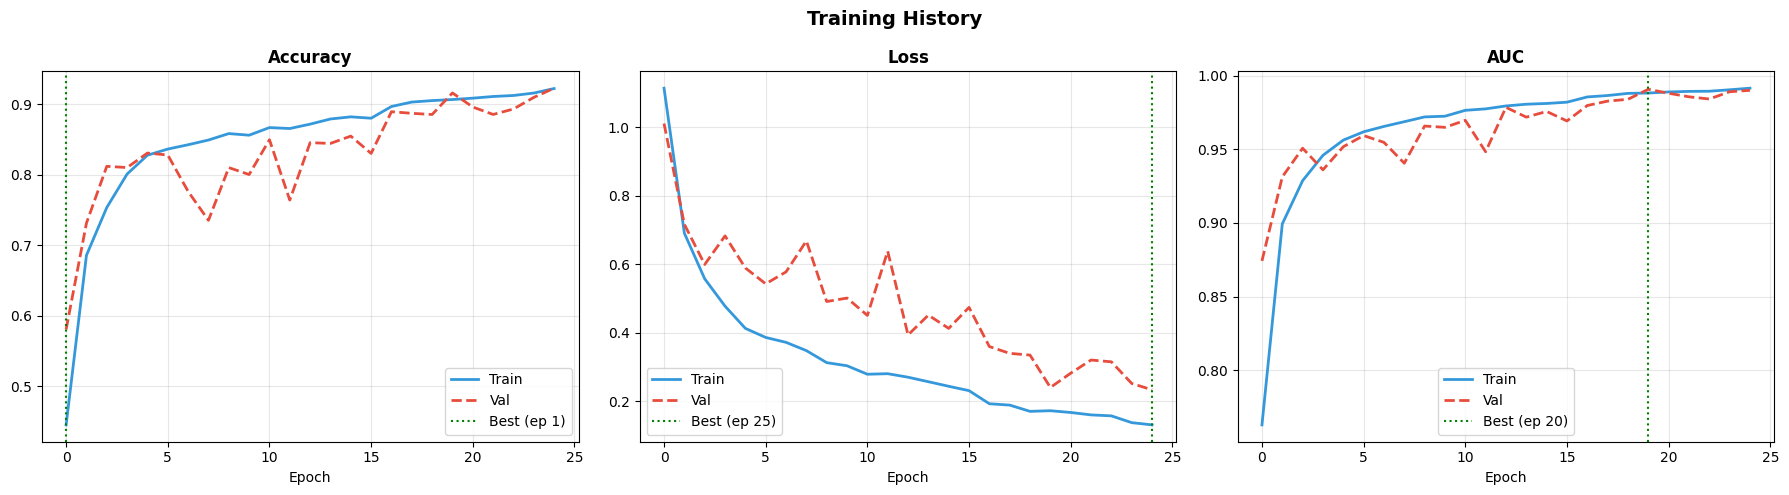

✅ Training history saved


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

metrics = [('accuracy','val_accuracy','Accuracy'),
           ('loss',    'val_loss',    'Loss'),
           ('auc',     'val_auc',     'AUC')]

for ax, (tr_m, val_m, title) in zip(axes, metrics):
    ax.plot(history.history[tr_m],  label='Train', linewidth=2, color='#3498db')
    ax.plot(history.history[val_m], label='Val',   linewidth=2, color='#e74c3c', linestyle='--')
    best_epoch = np.argmax(history.history[val_m]) if title=='AUC' else np.argmin(history.history[val_m])
    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5, label=f'Best (ep {best_epoch+1})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training history saved')

  FULL MODEL EVALUATION

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

           N       0.99      0.91      0.95     18118
           S       0.34      0.86      0.49       556
           V       0.91      0.92      0.92      1448
           F       0.19      0.94      0.32       162
           Q       0.95      0.99      0.97      1608

    accuracy                           0.91     21892
   macro avg       0.68      0.92      0.73     21892
weighted avg       0.96      0.91      0.93     21892



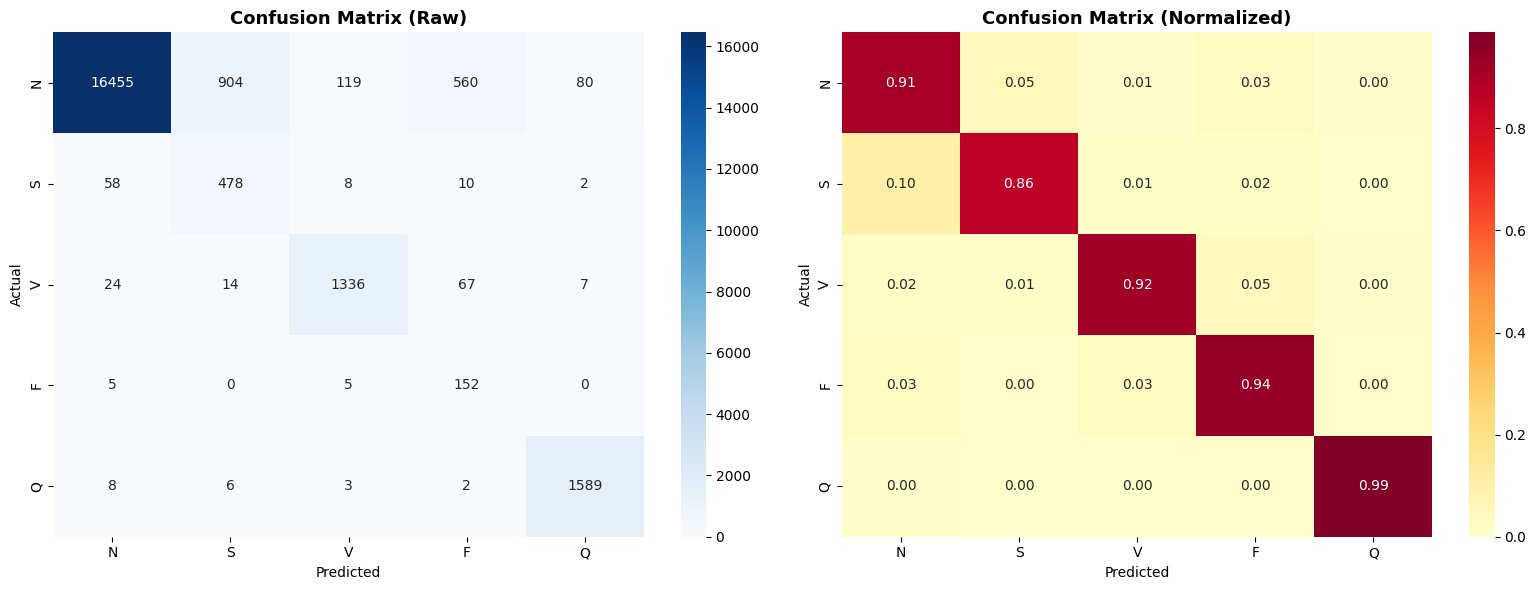

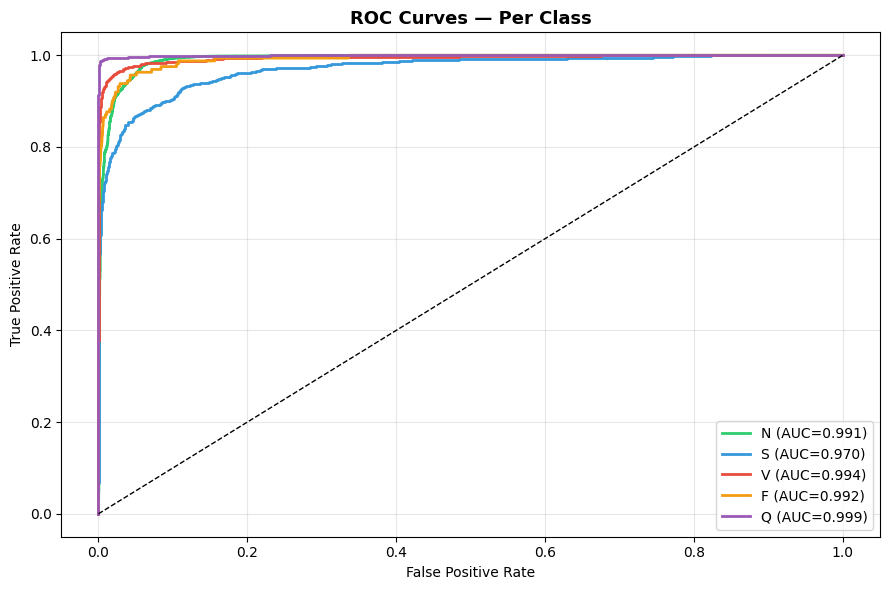

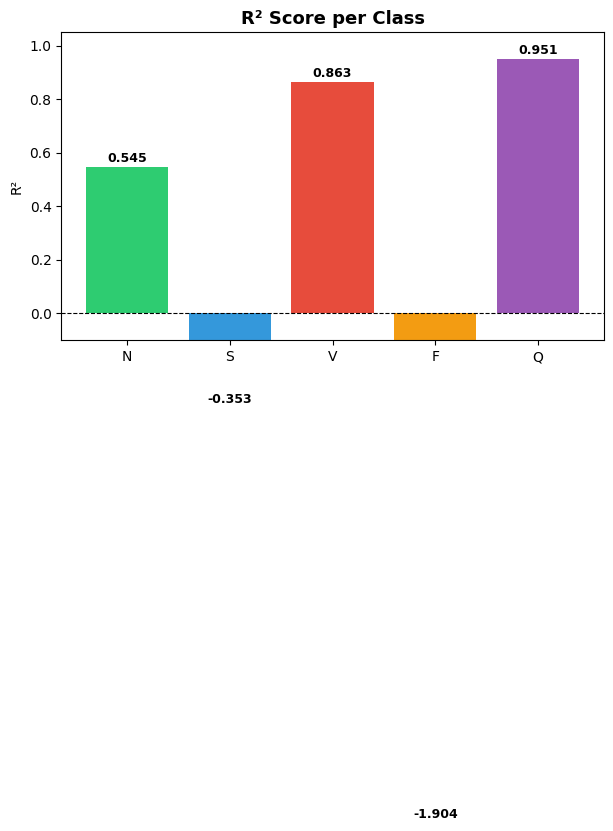

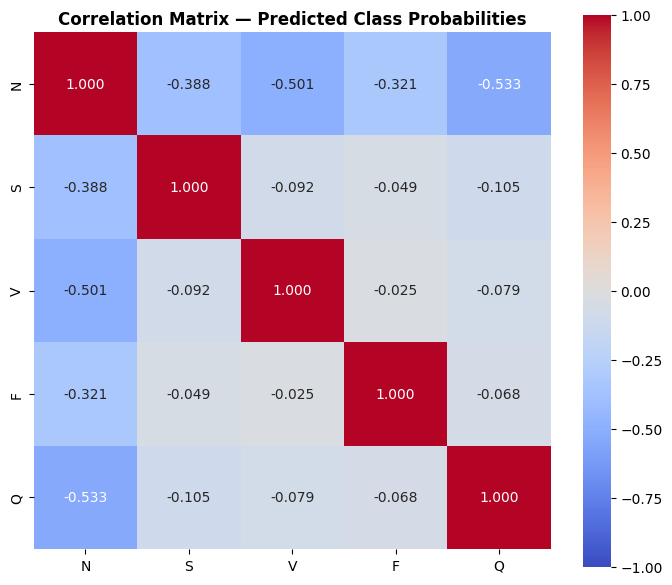


── SUMMARY ────────────────────────────────────────────
   Overall Accuracy : 91.40%
   Macro AUC        : 0.9894
   Macro R²         : 0.0204
   AUC [N]         : 0.9915
   AUC [S]         : 0.9701
   AUC [V]         : 0.9943
   AUC [F]         : 0.9915
   AUC [Q]         : 0.9994
✅ Evaluation complete — all plots saved


In [17]:
print('='*60)
print('  FULL MODEL EVALUATION')
print('='*60)

y_prob = model.predict(X_te, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_te_raw

# ── Classification Report ────────────────────────────────────
print('\n── Classification Report ──────────────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASS_SHORT))

# ── Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC-AUC ──────────────────────────────────────────────────
y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))
fig, ax = plt.subplots(figsize=(9, 6))
auc_scores = {}
for i, (cls, col) in enumerate(zip(CLASS_SHORT, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('ROC Curves — Per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── R² Score ─────────────────────────────────────────────────
r2_scores = {cls: r2_score(y_te_cat[:, i], y_prob[:, i]) for i, cls in enumerate(CLASS_SHORT)}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(CLASS_SHORT, list(r2_scores.values()), color=COLORS)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('R² Score per Class', fontsize=13, fontweight='bold')
ax.set_ylabel('R²'); ax.set_ylim(-0.1, 1.05)
for i, (cls, v) in enumerate(r2_scores.items()):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('r2_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation Matrix ───────────────────────────────────────
prob_df = pd.DataFrame(y_prob, columns=CLASS_SHORT)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(prob_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Predicted Class Probabilities',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────
print('\n── SUMMARY ────────────────────────────────────────────')
print(f'   Overall Accuracy : {np.mean(y_pred == y_true)*100:.2f}%')
print(f'   Macro AUC        : {np.mean(list(auc_scores.values())):.4f}')
print(f'   Macro R²         : {np.mean(list(r2_scores.values())):.4f}')
for cls, score in auc_scores.items():
    print(f'   AUC [{cls}]         : {score:.4f}')
print('='*60)
print('✅ Evaluation complete — all plots saved')